In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 11

RANDOM_SEED = 42

COLUMNS = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
           "hours-per-week", "native-country", "income"]
CONTINUOUS = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
FEATURES = [c for c in COLUMNS if c not in ("income", "fnlwgt")]
TARGET = "income"
POSITIVE = ">50K"      # класс, относительно которого считаются precision, recall и F


def load_dataset(path, skiprows=0):
    df = pd.read_csv(path, header=None, names=COLUMNS, skiprows=skiprows,
                     skipinitialspace=True, na_values=["?"])
    df[TARGET] = df[TARGET].astype(str).str.rstrip(".")   # в adult.test метки с точкой
    return df.fillna("Unknown")                           # пропуски -> отдельная категория


df_train = load_dataset("adult.data")
df_test = load_dataset("adult.test", skiprows=1)          # первая строка служебная

print(f"Обучающая выборка: {len(df_train)} записей")
print(f"Тестовая выборка:  {len(df_test)} записей")
print("\nРаспределение классов в обучающей выборке:")
print(df_train[TARGET].value_counts(normalize=True).round(4))
df_train.head()

Обучающая выборка: 32561 записей
Тестовая выборка:  16281 записей

Распределение классов в обучающей выборке:
income
<=50K    0.7592
>50K     0.2408
Name: proportion, dtype: float64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Реализация

Дерево строится рекурсивно: в каждом узле перебираются все атрибуты, для каждого считается
качество разбиения по выбранному критерию, побеждает атрибут с максимальным значением.
Категориальные атрибуты дают по ветви на каждое значение (и больше не используются ниже
по ветви), числовые — бинарное разбиение $A \le t$ / $A > t$ с подбором порога по квантилям.

Разбиение узла прекращается, если достигнута глубина `max_depth`, в узле меньше
`min_samples` наблюдений, все наблюдения одного класса или ни одно разбиение не даёт
прироста. Лист помечается преобладающим в нём классом.

In [2]:
def entropy(counts):
    """Info(S) = -sum p_i * log2(p_i)"""
    p = counts[counts > 0] / counts.sum()
    return -(p * np.log2(p)).sum()


def gini(counts):
    """Gini(S) = 1 - sum p_i^2"""
    p = counts / counts.sum()
    return 1 - (p * p).sum()


CRITERIA = ["information_gain", "gain_ratio", "gini"]
CRITERION_LABEL = {"information_gain": "Information gain",
                   "gain_ratio": "Gain ratio",
                   "gini": "Gini index"}
N_THRESHOLDS = 16      # сколько порогов перебирать для числового атрибута

In [3]:
class DecisionTree:
    """
    Дерево решений.
      criterion   — критерий выбора атрибута: information_gain | gain_ratio | gini
      max_depth   — предельная глубина дерева
      min_samples — минимальный размер узла, который ещё разбивается
    """

    def __init__(self, criterion="information_gain", max_depth=8, min_samples=100):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.impurity = gini if criterion == "gini" else entropy

    # ---------------------------------------------------------------- обучение
    def fit(self, X, y):
        self.classes_ = np.array(sorted(pd.unique(y)))
        self.n_leaves = 0
        self.root = self._build(X.reset_index(drop=True),
                                np.asarray(y), depth=0, used=set())
        return self

    def _counts(self, y):
        """Вектор частот классов в узле."""
        return np.array([(y == c).sum() for c in self.classes_], dtype=float)

    def _build(self, X, y, depth, used):
        counts = self._counts(y)
        node = {"n": len(y), "counts": counts, "leaf": True,
                "class": self.classes_[counts.argmax()]}

        if depth >= self.max_depth or len(y) < self.min_samples or (counts > 0).sum() <= 1:
            self.n_leaves += 1
            return node

        split = self._best_split(X, y, used)
        if split is None:
            self.n_leaves += 1
            return node

        attr, labels, masks, threshold = split
        node.update({"leaf": False, "attr": attr, "labels": labels, "threshold": threshold})
        next_used = used if attr in CONTINUOUS else used | {attr}
        node["children"] = [self._build(X[m], y[m], depth + 1, next_used) for m in masks]
        return node

    # ------------------------------------------------------- выбор разбиения
    def _score(self, y, masks, parent_impurity):
        """Прирост и итоговая оценка разбиения по выбранному критерию."""
        n = len(y)
        children = sum((m.sum() / n) * self.impurity(self._counts(y[m])) for m in masks)
        gain = parent_impurity - children
        if self.criterion != "gain_ratio":
            return gain, gain
        p = np.array([m.sum() / n for m in masks])
        p = p[p > 0]
        split_info = -(p * np.log2(p)).sum()
        return gain, (gain / split_info if split_info > 1e-12 else 0.0)

    def _best_split(self, X, y, used):
        parent_impurity = self.impurity(self._counts(y))
        best_per_attr = []

        for attr in FEATURES:
            col = X[attr].to_numpy()
            options = []
            if attr in CONTINUOUS:
                # пороги — квантили значений атрибута в узле
                for t in np.unique(np.quantile(col, np.linspace(0, 1, N_THRESHOLDS + 2)[1:-1])):
                    masks = [col <= t, col > t]
                    if min(m.sum() for m in masks) >= 10:
                        gain, score = self._score(y, masks, parent_impurity)
                        options.append((gain, score, [f"<= {t:g}", f"> {t:g}"], masks, t))
            elif attr not in used:
                values = sorted(pd.unique(col))
                if len(values) >= 2:
                    masks = [col == v for v in values]
                    gain, score = self._score(y, masks, parent_impurity)
                    options.append((gain, score, [str(v) for v in values], masks, None))
            if options:
                # для gain ratio порог выбирается по приросту, нормировка — к выбранному
                key = 0 if self.criterion == "gain_ratio" else 1
                best_per_attr.append((attr, max(options, key=lambda o: o[key])))

        if not best_per_attr:
            return None

        # Эвристика C4.5: у gain ratio знаменатель SplitInfo -> 0 на разбиениях,
        # отщепляющих крошечную ветвь. Поэтому рассматриваем только атрибуты,
        # чей абсолютный прирост не ниже среднего по узлу.
        if self.criterion == "gain_ratio":
            mean_gain = np.mean([opt[0] for _, opt in best_per_attr])
            best_per_attr = [c for c in best_per_attr if c[1][0] >= mean_gain] or best_per_attr

        attr, (gain, score, labels, masks, threshold) = max(best_per_attr,
                                                           key=lambda c: c[1][1])
        return (attr, labels, masks, threshold) if score > 1e-7 else None

    # ------------------------------------------------------------ применение
    def predict(self, X):
        return np.array([self._classify(row) for row in X[FEATURES].to_dict("records")])

    def _classify(self, row):
        node = self.root
        while not node["leaf"]:
            value = row[node["attr"]]
            if node["attr"] in CONTINUOUS:
                node = node["children"][0 if value <= node["threshold"] else 1]
            elif str(value) in node["labels"]:
                node = node["children"][node["labels"].index(str(value))]
            else:
                break        # значение не встречалось при обучении
        return node["class"]

In [4]:
def classification_metrics(y_true, y_pred, positive=POSITIVE):
    """Accuracy, precision, recall и F-мера относительно положительного класса."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = ((y_pred == positive) & (y_true == positive)).sum()
    fp = ((y_pred == positive) & (y_true != positive)).sum()
    fn = ((y_pred != positive) & (y_true == positive)).sum()

    accuracy = (y_pred == y_true).mean()
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def split_by_fraction(df, train_fraction, seed=RANDOM_SEED):
    """Случайное разбиение набора на обучающую и тестовую выборки в заданной пропорции."""
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_train = int(round(len(df) * train_fraction))
    return shuffled.iloc[:n_train], shuffled.iloc[n_train:]


def run_classification(df_tr, df_te, criterion, max_depth=8):
    """Построить дерево по обучающей выборке и оценить его на тестовой."""
    t0 = time.perf_counter()
    tree = DecisionTree(criterion=criterion, max_depth=max_depth)
    tree.fit(df_tr[FEATURES], df_tr[TARGET])
    fit_time = time.perf_counter() - t0

    result = classification_metrics(df_te[TARGET], tree.predict(df_te))
    result.update({"criterion": criterion, "leaves": tree.n_leaves,
                   "n_train": len(df_tr), "n_test": len(df_te), "fit_time": fit_time})
    return tree, result

## 4. Построение деревьев на 100 % исходных данных (п. 2 задания)

Дерево строится по всей обучающей выборке `adult.data`, качество проверяется на независимой
тестовой выборке `adult.test`. Эксперимент повторяется для каждого критерия.

In [5]:
trees = {}
rows = []
for criterion in CRITERIA:
    tree, result = run_classification(df_train, df_test, criterion)
    trees[criterion] = tree
    rows.append(result)
    print(f"{CRITERION_LABEL[criterion]:<18} листьев {result['leaves']:>5}, "
          f"построено за {result['fit_time']:.1f} с")

df_full = pd.DataFrame(rows)
table = df_full[["criterion", "leaves", "accuracy", "precision", "recall", "f1"]].copy()
table["criterion"] = table["criterion"].map(CRITERION_LABEL)
table.columns = ["Критерий", "Листьев", "Accuracy", "Precision", "Recall", "F-мера"]
table.round(4)

Information gain   листьев  1379, построено за 2.0 с
Gain ratio         листьев   714, построено за 2.0 с
Gini index         листьев  1515, построено за 2.1 с


,Критерий,Листьев,Accuracy,Precision,Recall,F-мера
0,Information gain,1379,0.8407,0.6972,0.5754,0.6305
1,Gain ratio,714,0.8592,0.7959,0.5434,0.6459
2,Gini index,1515,0.8421,0.6966,0.5874,0.6373


## 5. Визуализация деревьев (п. 3 и 6 задания)

Деревья содержат сотни листьев, поэтому показаны три верхних уровня — именно они задают
основную логику классификации. В узле указаны атрибут разбиения, число попавших в узел
наблюдений `n` и их распределение по классам `[<=50K / >50K]`; цвет узла — преобладающий
класс. Если ветвей больше, чем помещается на рисунке, их число указано отдельной пометкой.

In [6]:
COLORS = ["#cfe3f7", "#f8d3b4"]       # заливка узла: <=50K / >50K
EDGES = ["#7fa8d0", "#d79a63"]        # цвет рамки


def plot_tree(tree, max_depth=2, max_children=4, title=""):
    """Горизонтальная (слева направо) визуализация верхних уровней дерева."""
    rows = [0.0]          # счётчик занятых строк
    positions = {}

    def layout(node, depth):
        """Листьям выдаём по строке, внутренним узлам — середину между детьми."""
        kids = children_to_show(node, depth)
        if not kids:
            y = rows[0]
            rows[0] -= 1.0
        else:
            ys = [layout(child, depth + 1) for _, child in kids]
            if len(kids) < len(node["children"]):
                rows[0] -= 1.0        # строка под пометку «ещё N ветвей»
            y = (min(ys) + max(ys)) / 2
        positions[id(node)] = (depth, y)
        return y

    def children_to_show(node, depth):
        if node["leaf"] or depth >= max_depth:
            return []
        pairs = sorted(zip(node["labels"], node["children"]), key=lambda p: -p[1]["n"])
        return pairs[:max_children]

    layout(tree.root, 0)
    fig, ax = plt.subplots(figsize=(2.4 + (max_depth + 1) * 2.05,
                                    max(-rows[0] * 0.62 + 1.2, 3.0)))
    ax.set_axis_off()

    def draw(node, depth, parent=None, edge_label=None):
        x, y = positions[id(node)]
        kids = children_to_show(node, depth)
        distribution = " / ".join(str(int(c)) for c in node["counts"])
        head = f"{node['attr']} ?" if kids else str(node["class"])
        k = int(node["counts"].argmax())
        ax.text(x, y, f"{head}\nn={node['n']}  [{distribution}]", ha="center", va="center",
                fontsize=10.5, fontweight="bold" if kids else "normal",
                linespacing=1.2, zorder=3,
                bbox=dict(boxstyle="round,pad=0.25", facecolor=COLORS[k],
                          edgecolor=EDGES[k], linewidth=1.1))

        if parent is not None:
            px, py = parent
            mid = px + (x - px) * 0.52
            ax.plot([px + 0.45, mid, mid, x - 0.45], [py, py, y, y],
                    color="#9aa3ab", lw=1.0, zorder=1)
            ax.text(x, y + 0.50, edge_label[:19], fontsize=8.5, ha="center", va="center",
                    color="#1d4a73", zorder=2,
                    bbox=dict(boxstyle="round,pad=0.10", fc="white", ec="none", alpha=0.95))

        for label, child in kids:
            draw(child, depth + 1, (x, y), label)

        hidden = len(node["children"]) - len(kids) if kids else 0
        if hidden:
            lowest = min(positions[id(child)][1] for _, child in kids)
            ax.text(x + 1.0, lowest - 1.0, f"… ещё {hidden} ветв.", fontsize=8.5,
                    color="#9b5a00", style="italic", ha="center", va="center")

    draw(tree.root, 0)
    ax.set_xlim(-0.78, max_depth + 0.88)
    ax.set_ylim(rows[0] - 0.2, 1.0)
    ax.set_title(title, fontsize=11, pad=10, loc="left")
    fig.tight_layout()
    plt.show()

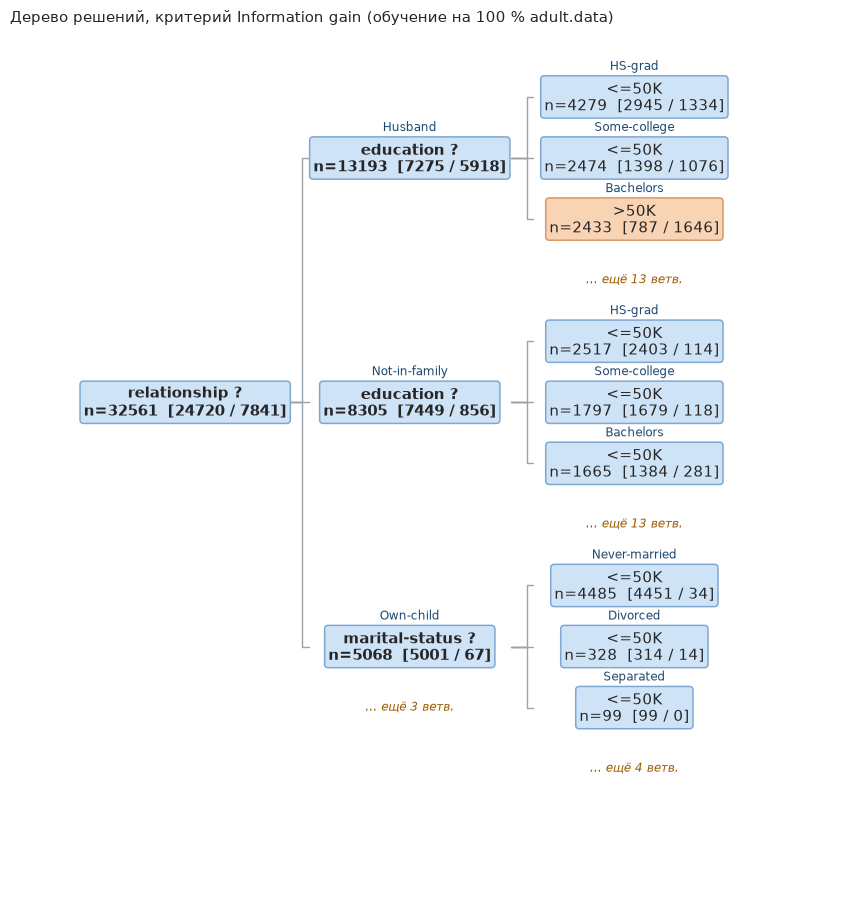

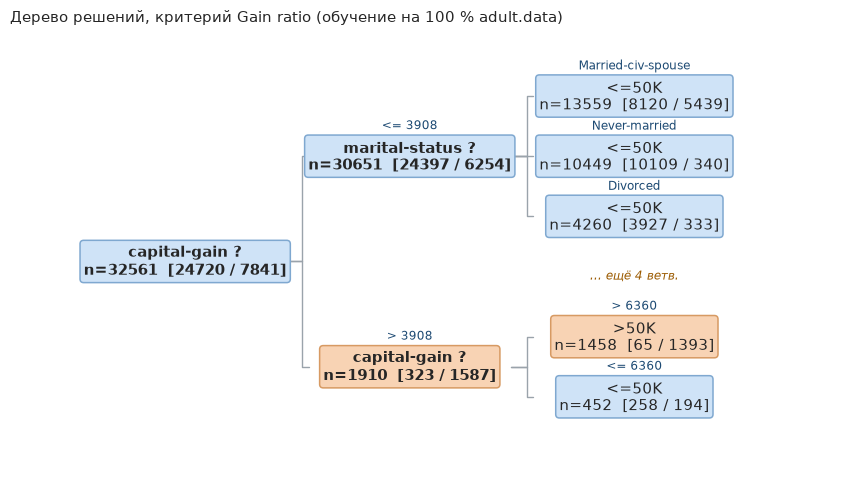

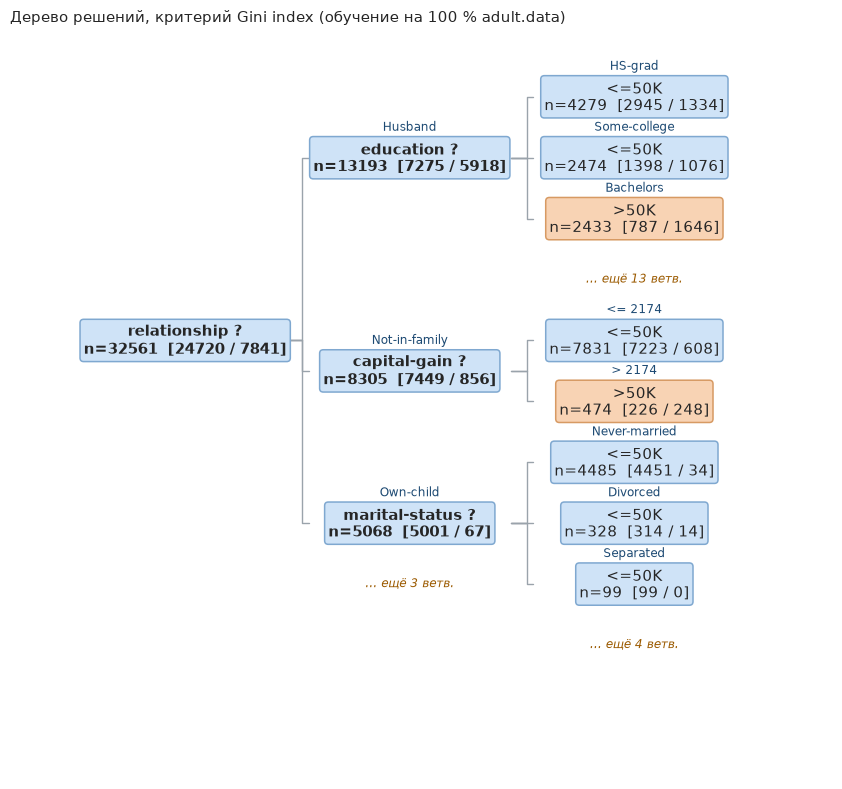

In [7]:
for criterion in CRITERIA:
    plot_tree(trees[criterion], max_depth=2, max_children=3,
              title=f"Дерево решений, критерий {CRITERION_LABEL[criterion]} "
                    f"(обучение на 100 % adult.data)")

## 6. Эксперименты с соотношением выборок (п. 4–5 задания)

Обучающая и тестовая выборки UCI объединяются в один набор (48 842 записи), который
случайным образом перемешивается и делится в заданной пропорции. Доля обучающей выборки
меняется от 60 % до 90 % с шагом 10 %, каждое значение — для каждого критерия.

In [8]:
df_all = pd.concat([df_train, df_test], ignore_index=True)
FRACTIONS = [0.6, 0.7, 0.8, 0.9]

experiments = []
for criterion in CRITERIA:
    for fraction in FRACTIONS:
        df_tr, df_te = split_by_fraction(df_all, fraction)
        _, result = run_classification(df_tr, df_te, criterion)
        result["ratio"] = f"{int(fraction * 100)}:{int(round((1 - fraction) * 100))}"
        experiments.append(result)
        print(f"{CRITERION_LABEL[criterion]:<18} {result['ratio']:>6}  "
              f"acc={result['accuracy']:.4f}  prec={result['precision']:.4f}  "
              f"rec={result['recall']:.4f}  F={result['f1']:.4f}")

df_exp = pd.DataFrame(experiments)
table = df_exp[["criterion", "ratio", "n_train", "n_test",
                "accuracy", "precision", "recall", "f1", "leaves"]].copy()
table["criterion"] = table["criterion"].map(CRITERION_LABEL)
table.columns = ["Критерий", "Обуч.:тест", "N обуч.", "N тест",
                 "Accuracy", "Precision", "Recall", "F-мера", "Листьев"]
table.round(4)

Information gain    60:40  acc=0.8399  prec=0.6996  rec=0.5701  F=0.6282
Information gain    70:30  acc=0.8428  prec=0.6979  rec=0.5944  F=0.6420
Information gain    80:20  acc=0.8398  prec=0.7020  rec=0.5764  F=0.6331
Information gain    90:10  acc=0.8450  prec=0.7138  rec=0.5761  F=0.6376
Gain ratio          60:40  acc=0.8561  prec=0.7842  rec=0.5431  F=0.6418
Gain ratio          70:30  acc=0.8583  prec=0.7981  rec=0.5383  F=0.6429
Gain ratio          80:20  acc=0.8514  prec=0.7912  rec=0.5162  F=0.6248
Gain ratio          90:10  acc=0.8618  prec=0.8127  rec=0.5407  F=0.6494
Gini index          60:40  acc=0.8427  prec=0.7052  rec=0.5794  F=0.6361
Gini index          70:30  acc=0.8447  prec=0.6990  rec=0.6062  F=0.6493
Gini index          80:20  acc=0.8441  prec=0.7114  rec=0.5884  F=0.6441
Gini index          90:10  acc=0.8489  prec=0.7262  rec=0.5804  F=0.6452


,Критерий,Обуч.:тест,N обуч.,N тест,Accuracy,Precision,Recall,F-мера,Листьев
0,Information gain,60:40,29305,19537,0.8399,0.6996,0.5701,0.6282,1288
1,Information gain,70:30,34189,14653,0.8428,0.6979,0.5944,0.6420,1443
2,Information gain,80:20,39074,9768,0.8398,0.7020,0.5764,0.6331,1667
3,Information gain,90:10,43958,4884,0.8450,0.7138,0.5761,0.6376,1835
4,Gain ratio,60:40,29305,19537,0.8561,0.7842,0.5431,0.6418,682
5,Gain ratio,70:30,34189,14653,0.8583,0.7981,0.5383,0.6429,770
6,Gain ratio,80:20,39074,9768,0.8514,0.7912,0.5162,0.6248,780
7,Gain ratio,90:10,43958,4884,0.8618,0.8127,0.5407,0.6494,844
8,Gini index,60:40,29305,19537,0.8427,0.7052,0.5794,0.6361,1345
9,Gini index,70:30,34189,14653,0.8447,0.6990,0.6062,0.6493,1557


### Показатели качества в зависимости от соотношения мощностей выборок

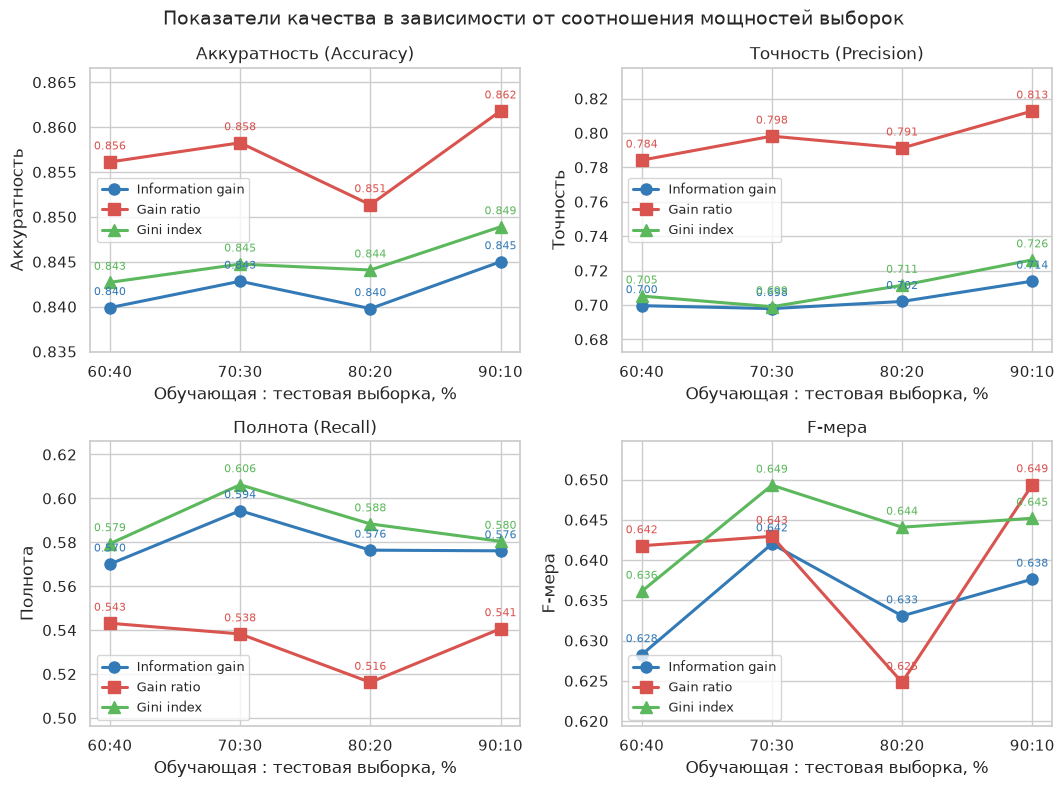

In [9]:
METRICS = [("accuracy", "Аккуратность (Accuracy)"), ("precision", "Точность (Precision)"),
           ("recall", "Полнота (Recall)"), ("f1", "F-мера")]
MARKERS = {"information_gain": "o", "gain_ratio": "s", "gini": "^"}
LINE_COLORS = {"information_gain": "#337ab7", "gain_ratio": "#d9534f", "gini": "#5cb85c"}

fig, axes = plt.subplots(2, 2, figsize=(10.8, 8))
for ax, (metric, label) in zip(axes.ravel(), METRICS):
    for criterion in CRITERIA:
        sub = df_exp[df_exp["criterion"] == criterion]
        ax.plot(sub["ratio"], sub[metric], marker=MARKERS[criterion], markersize=8,
                linewidth=2.2, color=LINE_COLORS[criterion],
                label=CRITERION_LABEL[criterion])
        for _, row in sub.iterrows():
            ax.annotate(f"{row[metric]:.3f}", (row["ratio"], row[metric]), fontsize=8,
                        textcoords="offset points", xytext=(0, 9), ha="center",
                        color=LINE_COLORS[criterion])
    ax.set_title(label, fontsize=12.5)
    ax.set_xlabel("Обучающая : тестовая выборка, %")
    ax.set_ylabel(label.split(" (")[0])
    ax.margins(y=0.22)
    ax.legend(fontsize=9)

fig.suptitle("Показатели качества в зависимости от соотношения мощностей выборок",
             fontsize=13.5)
fig.tight_layout()
plt.show()

### Показатели качества при фиксированном критерии разбиения

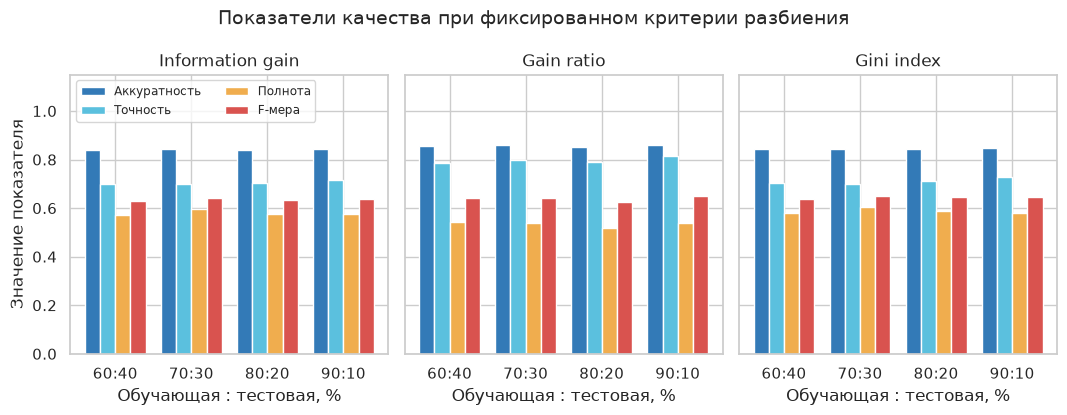

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10.8, 4.2), sharey=True)
bar_colors = ["#337ab7", "#5bc0de", "#f0ad4e", "#d9534f"]

for ax, criterion in zip(axes, CRITERIA):
    sub = df_exp[df_exp["criterion"] == criterion]
    x = np.arange(len(sub))
    for i, ((metric, label), color) in enumerate(zip(METRICS, bar_colors)):
        ax.bar(x + (i - 1.5) * 0.2, sub[metric], 0.2,
               label=label.split(" (")[0], color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["ratio"])
    ax.set_title(CRITERION_LABEL[criterion], fontsize=12)
    ax.set_xlabel("Обучающая : тестовая, %")
    ax.set_ylim(0, 1.15)

axes[0].set_ylabel("Значение показателя")
axes[0].legend(fontsize=8.5, loc="upper left", ncol=2)
fig.suptitle("Показатели качества при фиксированном критерии разбиения", fontsize=13.5)
fig.tight_layout()
plt.show()

## 7. Выводы

**Структура деревьев.** Information gain и Gini index выбрали корнем `relationship` — роль
в домохозяйстве; на втором уровне в самой крупной ветви («мужья») оба выбрали `education`,
в остальных — `education`, `capital-gain` или `marital-status` в зависимости от ветви. Это
содержательно верно: статус в семье задаёт базовый уровень дохода, образование его уточняет
(среди «мужей» доход `>50K` имеют 5918 из 13 193, то есть 45 % против 24 % по всей выборке,
причём у бакалавров этот класс уже преобладает — 1646 из 2433). Gain ratio выбрал корнем
`capital-gain`: в ветви с приростом капитала выше 3908 класс `>50K` преобладает (1587 из
1910), а при пороге выше 6360 он составляет уже 1393 из 1458. Расхождение
объясняется нормировкой на $SplitInfo$: разбиение по `relationship` даёт больший прирост, но
дробит выборку на 6 ветвей, а бинарное разбиение по `capital-gain` делит её на две сильно
неравные части, поэтому отношение $Gain/SplitInfo$ у него выше. Именно для этого gain ratio
и нужен — он компенсирует склонность information gain выбирать атрибуты с большим числом
значений (в наборе это, например, `native-country` с 42 значениями).

**Качество классификации.** Все три критерия дают 84–86 % аккуратности при тривиальном
базовом уровне 76 % (доля класса `<=50K`), то есть деревья действительно извлекают
закономерность, а не эксплуатируют дисбаланс классов. По F-мере критерии близки
(0.631–0.646), но ведут себя по-разному: gain ratio строит дерево вдвое компактнее
(714 листьев против 1379 и 1515) и даёт наивысшие аккуратность 0.8592 и точность 0.7959 при
наименьшей полноте 0.5434; Gini index, наоборот, даёт наивысшую полноту 0.5874. Точность у
всех заметно выше полноты: класс `>50K` составляет лишь 24 % выборки, поэтому в спорных
листьях побеждает метка `<=50K` и часть высокодоходных респондентов пропускается.

**Влияние соотношения выборок.** При росте доли обучающей выборки с 60 % до 90 %
аккуратность прибавляет около 0.5 процентного пункта (information gain 0.8399 → 0.8450,
gain ratio 0.8561 → 0.8618, gini 0.8427 → 0.8489), F-мера — около 1 пункта. Зависимость не
строго монотонна: у всех трёх критериев заметен провал на соотношении 80:20. Это не свойство
модели, а погрешность оценки — тестовая выборка сжимается с 19 537 записей при 60:40 до
4 884 при 90:10, и колебания в несколько десятых процента укладываются в эту погрешность.
Общая картина — выход на плато кривой обучения: даже 60 % набора достаточно для надёжной
оценки статистик в узлах, а дальнейшая точность ограничена уже не объёмом данных, а глубиной
дерева и разделимостью классов по имеющимся признакам. Ранжирование критериев при этом не
меняется, то есть выбор критерия и выбор пропорции разбиения — независимые решения.